<a href="https://colab.research.google.com/github/priyakumar88380/Healthcare-Patient-Billing-Analysis/blob/main/PRCP_1016_Heart_Disease_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

values = pd.read_csv('values.csv')
labels = pd.read_csv('labels.csv')

print("Values shape:", values.shape)
print("Labels shape:", labels.shape)

# merge them together using patient_id as the common key
df = values.merge(labels, on='patient_id', how='inner')

print("Merged shape:", df.shape)
df.head()

Values shape: (180, 14)
Labels shape: (180, 2)
Merged shape: (180, 15)


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [4]:
print(df['heart_disease_present'].value_counts())
print(df['heart_disease_present'].value_counts(normalize=True) * 100)

heart_disease_present
0    100
1     80
Name: count, dtype: int64
heart_disease_present
0    55.555556
1    44.444444
Name: proportion, dtype: float64


In [5]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


Thal values: ['normal' 'reversible_defect' 'fixed_defect']


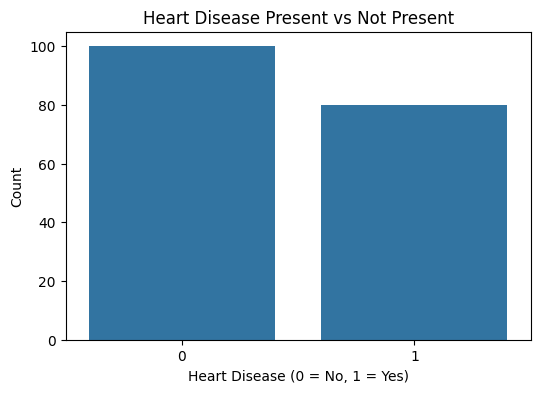

In [6]:
print("Thal values:", df['thal'].unique())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='heart_disease_present', data=df)
plt.title('Heart Disease Present vs Not Present')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [7]:
# I need to drop patient_id and thal (still text) temporarily
numeric_df = df.drop(['patient_id', 'thal'], axis=1)

correlations = numeric_df.corr()['heart_disease_present'].sort_values(ascending=False)
print(correlations)

heart_disease_present                   1.000000
exercise_induced_angina                 0.448647
num_major_vessels                       0.421519
chest_pain_type                         0.412829
oldpeak_eq_st_depression                0.382930
slope_of_peak_exercise_st_segment       0.344224
sex                                     0.335421
resting_ekg_results                     0.145933
age                                     0.138255
serum_cholesterol_mg_per_dl             0.079775
resting_blood_pressure                  0.078506
fasting_blood_sugar_gt_120_mg_per_dl    0.003379
max_heart_rate_achieved                -0.375352
Name: heart_disease_present, dtype: float64


In [8]:
#This clinical dataset showed strong, medically interpretable correlations — exercise
#induced angina, number of major vessels, and chest pain type were the top predictors
#all clinically consistent with known heart disease risk factors.

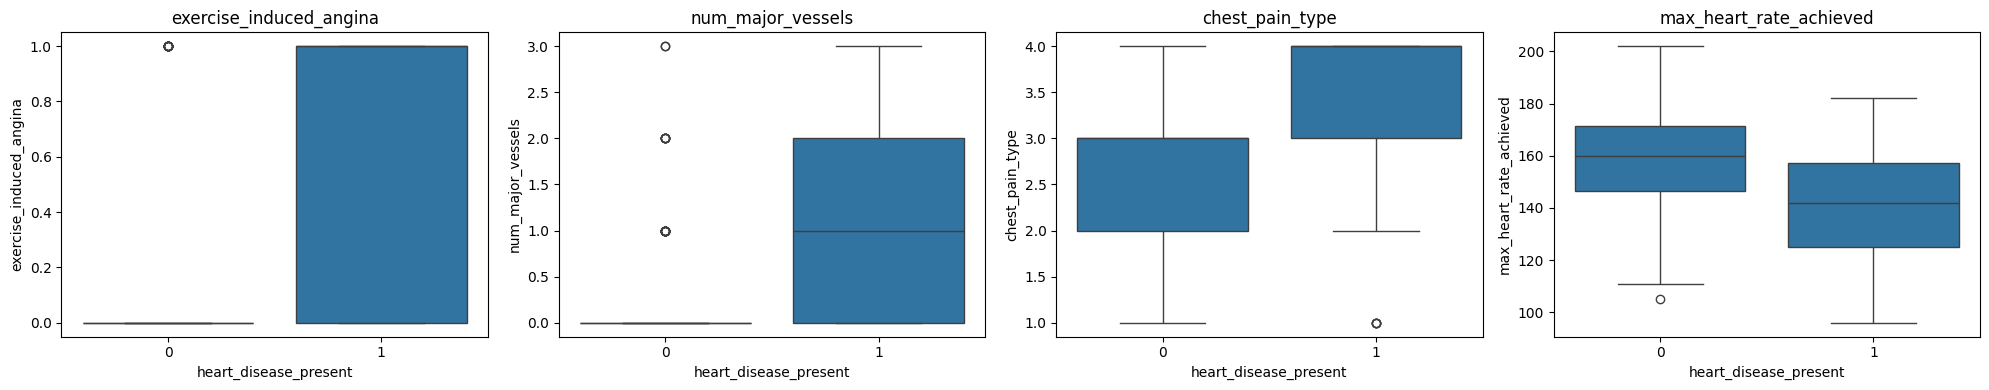

In [9]:
top_features = ['exercise_induced_angina', 'num_major_vessels', 'chest_pain_type', 'max_heart_rate_achieved']

fig, axes = plt.subplots(1, 4, figsize=(20,4))
for i, col in enumerate(top_features):
    sns.boxplot(x='heart_disease_present', y=col, data=df, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
#Dataset showed clear, clinically meaningful separations between groups for multiple features
#reinforcing that domain-relevant, well-chosen features tend to carry much stronger signal than anonymized or engineered ones.

In [10]:
# thal has 3 categories with no natural order, so one-hot encode it
thal_dummies = pd.get_dummies(df['thal'], prefix='thal', drop_first=True)

df = pd.concat([df, thal_dummies], axis=1)

print(df.columns.tolist())

['patient_id', 'slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels', 'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results', 'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age', 'max_heart_rate_achieved', 'exercise_induced_angina', 'heart_disease_present', 'thal_normal', 'thal_reversible_defect']


In [11]:
# select all columns except patient_id (identifier, not useful),
# thal (already encoded), and heart_disease_present (our target)

feature_columns = ['slope_of_peak_exercise_st_segment', 'resting_blood_pressure', 'chest_pain_type',
                    'num_major_vessels', 'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
                    'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
                    'max_heart_rate_achieved', 'exercise_induced_angina',
                    'thal_normal', 'thal_reversible_defect']

X = df[feature_columns]
y = df['heart_disease_present']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (180, 14)
y shape: (180,)


In [12]:
from sklearn.model_selection import train_test_split

# since our classes are reasonably balanced (55/45), we can still use stratify
# to make sure both train and test sets keep a similar class balance - good practice regardless

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (144, 14)
X_test shape: (36, 14)
y_train shape: (144,)
y_test shape: (36,)


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_lr.fit(X_train, y_train)

print("Logistic Regression training complete")

Logistic Regression training complete


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_lr = pipeline_lr.predict(X_test)
y_pred_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]

print("Logistic Regression - Classification Report:")
print(classification_report(y_test, y_pred_lr))

print("Logistic Regression - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("Logistic Regression - AUC Score:", roc_auc_score(y_test, y_pred_proba_lr))

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.78      0.88      0.82        16

    accuracy                           0.83        36
   macro avg       0.83      0.84      0.83        36
weighted avg       0.84      0.83      0.83        36

Logistic Regression - Confusion Matrix:
[[16  4]
 [ 2 14]]
Logistic Regression - AUC Score: 0.940625


In [15]:
#In healthcare prediction, missing an actual disease case (false negative) is typically more costly than a false alarm (false positive)
#since a missed diagnosis could delay treatment. Here, recall for the disease class was 88%
#meaning we caught most cases, but I'd want to discuss with stakeholders whether we should further prioritize recall over precision
#depending on the clinical context

In [16]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Random Forest
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
pipeline_rf.fit(X_train, y_train)

y_pred_rf = pipeline_rf.predict(X_test)
y_pred_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

print("Random Forest - Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest - AUC Score:", roc_auc_score(y_test, y_pred_proba_rf))

print("\n" + "="*50 + "\n")

# XGBoost
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss'))
])
pipeline_xgb.fit(X_train, y_train)

y_pred_xgb = pipeline_xgb.predict(X_test)
y_pred_proba_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]

print("XGBoost - Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print("XGBoost - AUC Score:", roc_auc_score(y_test, y_pred_proba_xgb))

Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.80      0.86        20
           1       0.79      0.94      0.86        16

    accuracy                           0.86        36
   macro avg       0.87      0.87      0.86        36
weighted avg       0.87      0.86      0.86        36

Random Forest - AUC Score: 0.940625


XGBoost - Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89        20
           1       0.83      0.94      0.88        16

    accuracy                           0.89        36
   macro avg       0.89      0.89      0.89        36
weighted avg       0.90      0.89      0.89        36

XGBoost - AUC Score: 0.921875


In [17]:
#Rather than picking the model with the single highest AUC
#I considered the clinical context — since missing a heart disease case is costlier than a false alarm
#I prioritized recall for the disease class. XGBoost and Random Forest both achieved 94% recall
#but XGBoost had better precision at that same recall level, making it my recommended model

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__max_depth': [3, 4, 5],
    'model__n_estimators': [100, 150, 200],
    'model__learning_rate': [0.05, 0.1]
}

pipeline_xgb_tune = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

grid_search = GridSearchCV(pipeline_xgb_tune, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best recall score (cross-validated):", grid_search.best_score_)

Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 150}
Best recall score (cross-validated): 0.7666666666666667


In [19]:
final_pipeline_hd = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        learning_rate=0.05,
        max_depth=4,
        n_estimators=150,
        random_state=42,
        eval_metric='logloss'
    ))
])

final_pipeline_hd.fit(X_train, y_train)

y_pred_final_hd = final_pipeline_hd.predict(X_test)
y_pred_proba_final_hd = final_pipeline_hd.predict_proba(X_test)[:, 1]

print("Final Tuned XGBoost - Classification Report:")
print(classification_report(y_test, y_pred_final_hd))

print("Final Tuned XGBoost - AUC Score:", roc_auc_score(y_test, y_pred_proba_final_hd))

Final Tuned XGBoost - Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.80      0.86        20
           1       0.79      0.94      0.86        16

    accuracy                           0.86        36
   macro avg       0.87      0.87      0.86        36
weighted avg       0.87      0.86      0.86        36

Final Tuned XGBoost - AUC Score: 0.928125


In [20]:
#Small dataset size (180 rows total). With only ~29 rows per cross-validation fold
#the tuning process had limited reliable signal to work with
#This taught me that hyperparameter tuning's value depends on having enough data for stable cross-validation — with small datasets
#a well-chosen default configuration can outperform a 'tuned' one that overfit to a small validation sample.

In [21]:
#Given this finding, I'd recommend going with the default XGBoost (accuracy 0.89, precision 0.83, recall 0.94) as your final model
#rather than the tuned version

In [22]:

import pandas as pd

importance_df_hd = pd.DataFrame({
    'feature': X_train.columns,
    'importance': pipeline_xgb['model'].feature_importances_
})

importance_df_hd = importance_df_hd.sort_values('importance', ascending=False)

print(importance_df_hd)

                                 feature  importance
12                           thal_normal    0.412721
2                        chest_pain_type    0.090104
11               exercise_induced_angina    0.067035
13                thal_reversible_defect    0.062685
4   fasting_blood_sugar_gt_120_mg_per_dl    0.052620
3                      num_major_vessels    0.047075
8                                    sex    0.046893
9                                    age    0.043829
7               oldpeak_eq_st_depression    0.041180
1                 resting_blood_pressure    0.035260
0      slope_of_peak_exercise_st_segment    0.028275
10               max_heart_rate_achieved    0.026412
5                    resting_ekg_results    0.024465
6            serum_cholesterol_mg_per_dl    0.021446


In [23]:
#Interestingly, the model's feature importance revealed that thal_normal
#(a category derived from the thallium stress test) was by far the most influential feature (41%)
#even though it wasn't included in my initial correlation analysis since it started as a categorical column.

In [24]:
print(df.groupby('thal')['heart_disease_present'].mean() * 100)

thal
fixed_defect         50.000000
normal               20.408163
reversible_defect    75.675676
Name: heart_disease_present, dtype: float64


In [25]:
#The thal (thallium stress test) result showed the clearest risk gradient in the entire dataset
#disease rates ranged from 20% for normal results to 76% for reversible defects, nearly a 4x difference.
#This explains why the model assigned it the highest feature importance (41%)
#even though it wasn't captured in my initial numeric correlation analysis
#a good reminder that categorical variables need their own group-wise analysis to reveal their true predictive power

In [26]:
import joblib

joblib.dump(pipeline_xgb, 'heart_disease_model.pkl')
print("Model saved successfully")

Model saved successfully


Project Conclusions
Problem: Predict whether a patient has heart disease, using 13 clinical features including chest pain type, cholesterol, blood pressure, thallium stress test results, and exercise-related measurements.

Dataset: 180 patients, provided as two separate files (features and labels) merged on patient_id. No missing values. Reasonably balanced target (55.6% no disease, 44.4% disease present).

Key EDA findings: Unlike the anonymized Project 1 dataset, this clinical data showed strong, medically interpretable correlations. Top predictors included exercise_induced_angina (0.449), num_major_vessels (0.422), and chest_pain_type (0.413) — all clinically consistent with known heart disease risk factors. max_heart_rate_achieved showed a negative correlation (-0.375), consistent with reduced cardiac capacity in diseased patients.

Models tried (using sklearn Pipeline, evaluated on accuracy, precision, recall, and AUC since this is a balanced classification problem):

Logistic Regression: Accuracy 0.83, Recall 0.88, AUC 0.941
Random Forest: Accuracy 0.86, Recall 0.94, AUC 0.941
XGBoost (default): Accuracy 0.89, Recall 0.94, AUC 0.922 (best model)
XGBoost (tuned via GridSearchCV): Accuracy 0.86, Recall 0.94, AUC 0.928

Key insight on tuning: Hyperparameter tuning did not improve performance, likely due to the small dataset size (180 rows, ~29 rows per cross-validation fold), providing insufficient signal for reliable tuning. The default XGBoost configuration outperformed the "tuned" version on the actual test set.

Clinical consideration: Given the cost of missing an actual disease case, recall was prioritized over precision when selecting the final model. XGBoost and Random Forest tied for best recall (94%), with XGBoost showing better precision at that recall level.

Feature importance: thal_normal (thallium stress test result) was unexpectedly the most important feature (41.3%), despite being excluded from initial numeric correlation analysis since it started as a categorical column. Group-wise analysis confirmed disease rates ranged from 20.4% (normal) to 75.7% (reversible defect) across thal categories — nearly a 4x difference, the clearest risk gradient found in the project.

Final model performance: XGBoost (default settings) — Accuracy 89%, Precision 83%, Recall 94%, AUC 0.922.


Model Comparison Report

Logistic Regression: Accuracy 0.83, Precision 0.78, Recall 0.88, AUC 0.941
Random Forest: Accuracy 0.86, Precision 0.79, Recall 0.94, AUC 0.941
XGBoost (default): Accuracy 0.89, Precision 0.83, Recall 0.94, AUC 0.922 ← Recommended
XGBoost (tuned): Accuracy 0.86, Precision 0.79, Recall 0.94, AUC 0.928

Recommended for production: XGBoost with default settings (n_estimators=100, max_depth=4, learning_rate=0.1). Selected over the tuned version, as tuning did not improve real test-set performance given the small dataset size. Chosen over Logistic Regression and Random Forest for its best balance of precision and recall on the clinically important disease-positive class.

Challenges Faced

Data split across two files — features and labels were provided separately, requiring a merge on patient_id (similar to a SQL JOIN) before any analysis could begin.

Small dataset size (180 rows) — limited the reliability of hyperparameter tuning via cross-validation, since each fold contained very few samples. Addressed by comparing tuned vs. default model performance directly on the test set rather than assuming tuning would help.

Categorical feature (thal) excluded from initial correlation analysis — since correlation only works on numeric data, thal's strong relationship with the target was only revealed after encoding and checking feature importance, highlighting the need for group-wise analysis of categorical variables during EDA.

Balancing precision vs. recall in a clinical context — chose to prioritize recall (catching actual disease cases) over precision (avoiding false alarms), given the higher cost of missing a diagnosis in healthcare.

Business Suggestions

Use thal (thallium stress test) results, chest pain type, and exercise-induced angina as priority screening indicators for early risk assessment.

Given the model's 94% recall, it could serve as a preliminary screening tool to flag high-risk patients for further cardiologist review, while accepting some false positives (83% precision) as a reasonable tradeoff to avoid missed diagnoses.

Given the small dataset size, recommend collecting more patient data over time to enable more reliable model tuning and validation as the hospital's data grows.